In [60]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Initial libraries and global variables

In [61]:
import numpy as np
import scipy.optimize as optimize
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from distinguishability_model import simulate, make_foi_fn, generate_state_holder
import copy
from sklearn.linear_model import LinearRegression


T_MAX = 100
TIME_EVAL = np.arange(0, T_MAX)

# Commuter data
Load commuter data and select Cambridge as the seed index

In [62]:
commuter_data = pd.read_csv("commuter_data/commuter_matrix.csv", index_col=0)
commuter_matrix = commuter_data.values
patch_ids = commuter_data.index.values
seed_id = np.where(patch_ids == 'E07000008')[0][0]

S0, I0, R0 = generate_state_holder(commuter_matrix, [seed_id], T_MAX, infected=10, collapsed=True)
N = S0.shape[1]

# Flatten initial conditions to match ODE solvers required format for model.
deterministic_ini = np.zeros(shape=3 * N)
deterministic_ini[::3] = S0[0, ...]
deterministic_ini[1::3] = I0[0, ...]
deterministic_ini[2::3] = R0[0, ...]

# Simulate distinguishable epidemic

In [63]:
def time_series(b, g, distinguish=True):
    s, i, r = simulate(beta=b, gamma=g, od_matrix=commuter_matrix,
                       t_max=T_MAX, seed_subpatch=[seed_id, seed_id], distinguish=distinguish)
    return s.sum(axis=1), i.sum(axis=1), r.sum(axis=1)

# Create baseline deterministic model

In [64]:
def deterministic_model(beta, gamma):
    """
    Solves deterministic meta-population model with given beta and gamma and commuter matrix.
    :param beta:
    :param gamma:
    :return:
    """
    foi_fn = make_foi_fn(beta=beta, od_matrix=commuter_matrix, distinguish=False, collapse=True)

    def transformer(t, state):
        """
        Transforms state for differential
        :param state:
        :return:
        """

        s = state[::3]
        i = state[1::3]
        r = state[2::3]

        foi = foi_fn(i)

        new_state = np.zeros_like(state)
        new_state[::3] = -foi * s
        new_state[1::3] = foi * s - gamma * i
        new_state[2::3] = gamma * i

        return new_state

    sol = solve_ivp(transformer, [0, T_MAX], deterministic_ini, t_eval=TIME_EVAL).y
    return sol[1::3, ...].T

In [73]:
def objective_function(params, data):
    """
    Returns negative log likelihood
    :param params:
    :param data:
    :return:
    """
    b, g = params
    s, i, r = data
    # shift S to the left and concatenate the final column to the end of this
    s_p = np.concatenate([s[1:, :], s[-1:, :]])
    i_p = np.concatenate([i[1:, :], i[-1:, :]])

    delta = s - s_p
    nabla = i - i_p + delta
    time = np.arange(s.shape[0])

    foi_fn = make_foi_fn(beta=b, od_matrix=commuter_matrix, distinguish=False, collapse=True)
    foi = foi_fn(i)
    # when delta is zero so is foi, so we can safely ignore those values in the logarithm despite it being log(0), this just stops log(0) from happening
    sane_foi = copy.deepcopy(foi)
    sane_foi[foi == 0] = 0
    sane_foi[foi != 0] = np.exp(-sane_foi[foi != 0])
    likelihood_delta = delta * np.log(1 - sane_foi) - (s - delta) * foi
    likelihood_nabla = nabla * np.log(1 - np.exp(-g)) - (i - nabla) * g
    return -likelihood_delta.sum(axis=(0, 1)) - likelihood_nabla.sum(axis=(0, 1))


def infer(beta, gamma,  distinguishable_data=True):
    simulated_data = time_series(beta, gamma,distinguish=distinguishable_data)
    result = optimize.minimize(objective_function,
                               np.array([1, 0.5]),
                               args=(simulated_data,),
                               method='L-BFGS-B',
                               bounds=((0.01, 10 * beta), (0.01, 10 * gamma)))
    return result.x

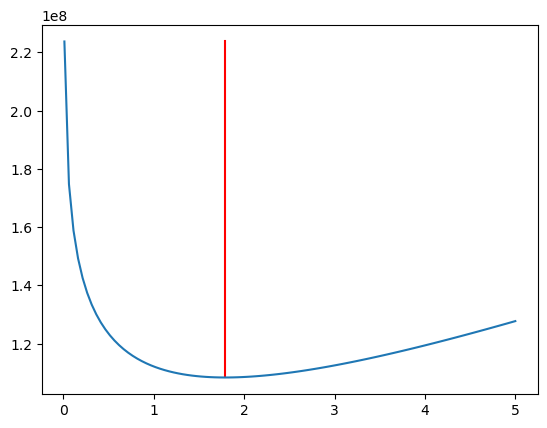

In [66]:
test_b, test_g = 1.85, 0.4
b_range = np.linspace(0.01, 5, 100)
data = time_series(test_b, test_g)
ll_slice = np.array([objective_function((b_param, 0.2), data) for b_param in b_range])
inferred_b, _ = infer(test_b, test_g)
line_x, line_y = np.repeat(inferred_b, 100), np.linspace(ll_slice.min(), ll_slice.max(), 100)
plt.plot(line_x, line_y, c='r')
plt.plot(b_range, ll_slice)
plt.show()

In [83]:
def fit_for_range(b_iters=10, g_iters=10, distinguishable_data=True):
    """
    Fits deterministic model to simulated data.
    :return: Dictionary with key:value = true_values:inferred_values
    """
    inferred = []
    true = []
    for beta in np.linspace(1, 4, b_iters):
        for  gamma in np.linspace(0.2, 0.7, g_iters):
            true.append(beta / gamma)
            i_b, i_g = infer(beta, gamma, distinguishable_data)
            inferred.append(i_b / i_g)
    return np.array(true), np.array(inferred)

In [84]:
d_true_r0, d_inferred_r0 = fit_for_range(distinguishable_data=True)
i_true_r0, i_inferred_r0 = fit_for_range(distinguishable_data=False)

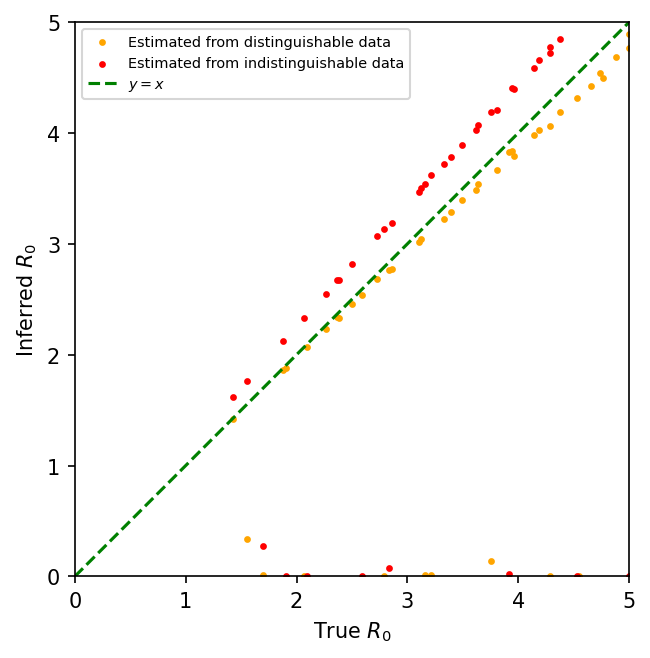

In [85]:
plt.scatter(d_true_r0, d_inferred_r0, s=5, c='orange', label='Estimated from distinguishable data')
plt.scatter(i_true_r0, i_inferred_r0, s=5, c='red', label='Estimated from indistinguishable data')
plt.xlabel('True $R_0$')
plt.ylabel('Inferred $R_0$')
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.gca().set_aspect('equal')
low, hi = plt.gca().get_xlim()
x_domain = np.linspace(low, hi, 100)
plt.plot(x_domain, x_domain, c='green', label='$y=x$', linestyle='--')
#reg = LinearRegression().fit(inferred_r0[inferred_r0>1].reshape(-1,1), true_r0[inferred_r0>1])

#y = reg.coef_[0]*x_domain + reg.intercept_
# plt.plot(x_domain, y, c='orange', label=f'$y={reg.coef_[0]:.2f}x+{reg.intercept_:.2f}$')


plt.legend(fontsize='x-small')
plt.gcf().set_dpi(150)
plt.show()